# Evaluate & Compare Models

Evaluate fine-tuned RT-DETR models, compare hyperparameter tuning runs, and select the best configuration.

**Sections:**
1. Evaluate a single model (mAP metrics)
2. Visualize predictions on sample images
3. Compare training runs (loss curves, final metrics)
4. HP tuning strategy & best model selection

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from transformers import RTDetrForObjectDetection

from moku.dataset import CATEGORIES, ID_TO_CATEGORY
from moku.training import (
    collate_fn,
    evaluate_map,
    format_map_per_class,
    format_map_results,
    load_image_processor,
    load_training_runs,
    make_eval_transform,
    summarize_runs,
)
from moku.viz import render_sample


## Load Dataset & Model

Load the test split and the best trained model from HF Hub (`kaya-go/moku-v1`).

Best config from grid search: `lr=5e-5, batch_size=4, weight_decay=1e-4`.

In [3]:
# Best model from grid search (pushed to HF Hub)
MODEL_PATH = "kaya-go/moku-v1"
DATASET_PATH = "kaya-go/moku-v1"

dataset = load_dataset(DATASET_PATH)
image_processor = load_image_processor()

model = RTDetrForObjectDetection.from_pretrained(
    MODEL_PATH,
    num_labels=len(CATEGORIES),
    id2label=ID_TO_CATEGORY,
    label2id=CATEGORIES,
)

dataset.set_transform(make_eval_transform(image_processor))
print(f"Model loaded from: {MODEL_PATH}")
print(f"Test set: {len(dataset['test'])} images")

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Model loaded from: kaya-go/moku-v1
Test set: 50 images


## Compute mAP Metrics

=== Overall Metrics ===


,metric,value
0,mAP@50:95,0.3995
1,mAP@50,0.7207
2,mAP@75,0.3725
3,mAR@400,0.5072



=== Per-Class AP ===


,category,AP@50:95
0,black_stone,0.5135
1,white_stone,0.4706
2,board_corner,0.2142


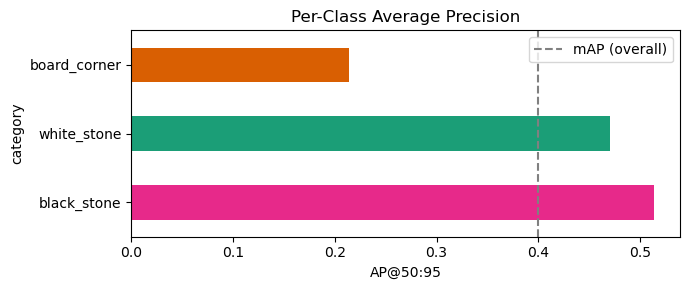

In [8]:
THRESHOLD = 0.05

metrics = evaluate_map(
    model=model,
    dataset=dataset["test"],
    image_processor=image_processor,
    batch_size=8,
    threshold=THRESHOLD,
)

print("=== Overall Metrics ===")
display(format_map_results(metrics))

print("\n=== Per-Class AP ===")
pc = format_map_per_class(metrics)
display(pc)

# Bar chart: per-class AP@50:95
ax = pc.plot.barh(x="category", y="AP@50:95", figsize=(7, 3), legend=False, color=["#e7298a", "#1b9e77", "#d95f02"])
ax.set_xlabel("AP@50:95")
ax.set_title("Per-Class Average Precision")
ax.axvline(float(metrics.get("map", 0)), color="gray", linestyle="--", label="mAP")
ax.legend(["mAP (overall)"])
plt.tight_layout()
plt.show()


## Visualize Predictions

Interactive viewer: browse test images and toggle between **predictions** and **ground truth** bounding boxes.

In [ ]:
import ipywidgets as widgets
from IPython.display import display as ipy_display

device = "cpu"

# Load raw test images (without transforms) for visualization
raw_test = load_dataset(MODEL_PATH, split="test")

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
model_viz = model.to(device)
model_viz.eval()

COLORS = {"black_stone": "#e7298a", "white_stone": "#1b9e77", "board_corner": "#d95f02"}


def _filter_predictions(preds, threshold):
    """Filter predictions by threshold; for board_corner, keep only top 4."""
    boxes, scores, labels = [], [], []
    corner_candidates = []
    for box, score, label_id in zip(preds["boxes"], preds["scores"], preds["labels"]):
        if score < threshold:
            continue
        if ID_TO_CATEGORY[label_id] == "board_corner":
            corner_candidates.append((box, score, label_id))
        else:
            boxes.append(box)
            scores.append(score)
            labels.append(label_id)
    corner_candidates.sort(key=lambda x: x[1], reverse=True)
    for box, score, label_id in corner_candidates[:4]:
        boxes.append(box)
        scores.append(score)
        labels.append(label_id)
    return boxes, scores, labels


def _draw_boxes(ax, image, boxes, scores, labels):
    """Draw bounding boxes on an axes. boxes in (x1, y1, x2, y2) format."""
    ax.imshow(image)
    for box, score, label_id in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        name = ID_TO_CATEGORY[label_id]
        color = COLORS[name]
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, f"{name} {score:.2f}", fontsize=7, color=color, weight="bold")
    ax.axis("off")


def _draw_gt(ax, image, sample):
    """Draw ground truth bounding boxes (COCO format: x, y, w, h)."""
    ax.imshow(image)
    for bbox, cat_id in zip(sample["objects"]["bbox"], sample["objects"]["category"]):
        x, y, w, h = bbox
        name = ID_TO_CATEGORY[cat_id]
        color = COLORS[name]
        rect = plt.Rectangle((x, y), w, h, linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 2, name, fontsize=7, color=color, weight="bold")
    ax.axis("off")


# Pre-compute all predictions without threshold (filtering done interactively)
print("Running inference on test set...")
all_predictions = []
for idx in range(len(raw_test)):
    sample = raw_test[idx]
    image = sample["image"].convert("RGB")
    inputs = image_processor(images=[image], return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_viz(**inputs)
    target_size = torch.tensor([[image.height, image.width]])
    results = image_processor.post_process_object_detection(
        outputs,
        target_sizes=target_size,
        threshold=0.0,
    )[0]
    all_predictions.append(
        {
            "boxes": results["boxes"].cpu().tolist(),
            "scores": results["scores"].cpu().tolist(),
            "labels": results["labels"].cpu().tolist(),
        }
    )
print(f"Done. {len(all_predictions)} images processed.")

# Interactive widget
output = widgets.Output()

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(raw_test) - 1,
    step=1,
    description="Image:",
)
toggle = widgets.ToggleButtons(
    options=["Predictions", "Ground Truth", "Both"],
    value="Both",
    description="Show:",
)
threshold_slider = widgets.FloatSlider(
    value=THRESHOLD,
    min=0.0,
    max=1.0,
    step=0.01,
    description="Threshold:",
    readout_format=".2f",
)


def update_viz(change=None):
    output.clear_output(wait=True)
    with output:
        idx = slider.value
        mode = toggle.value
        threshold = threshold_slider.value
        sample = raw_test[idx]
        image = sample["image"].convert("RGB")
        preds = all_predictions[idx]
        boxes, scores, labels = _filter_predictions(preds, threshold)

        if mode == "Both":
            fig, (ax_pred, ax_gt) = plt.subplots(1, 2, figsize=(18, 7))
            _draw_boxes(ax_pred, image, boxes, scores, labels)
            ax_pred.set_title(f"Predictions ({len(boxes)} detections)", fontsize=11)
            _draw_gt(ax_gt, image, sample)
            n_gt = len(sample["objects"]["bbox"])
            ax_gt.set_title(f"Ground Truth ({n_gt} annotations)", fontsize=11)
        elif mode == "Predictions":
            fig, ax = plt.subplots(1, 1, figsize=(10, 8))
            _draw_boxes(ax, image, boxes, scores, labels)
            ax.set_title(f"Predictions ({len(boxes)} detections)", fontsize=11)
        else:
            fig, ax = plt.subplots(1, 1, figsize=(10, 8))
            _draw_gt(ax, image, sample)
            n_gt = len(sample["objects"]["bbox"])
            ax.set_title(f"Ground Truth ({n_gt} annotations)", fontsize=11)

        fig.suptitle(f"Test image {idx}", fontsize=13, weight="bold")
        plt.tight_layout()
        plt.show()


slider.observe(update_viz, names="value")
toggle.observe(update_viz, names="value")
threshold_slider.observe(update_viz, names="value")

ipy_display(widgets.VBox([widgets.HBox([slider, toggle, threshold_slider]), output]))
update_viz()


Running inference on test set...
Done. 50 images processed.
